In [7]:
import os
import sys
import django
from asgiref.sync import sync_to_async
from django.db.models.functions import ExtractHour
import pandas as pd
from citas.models import Cita
import pandas as pd

# Añade la ruta del proyecto manualmente
sys.path.append("C:/Users/denis/Pictures/MACE")

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'MACE.settings')
django.setup()


async def obtener_datos_citas():
    qs = await sync_to_async(list)(
        Cita.objects
        .filter(profesor__isnull=False)
        .annotate(hora=ExtractHour('fecha_hora_inicio'))
        .values_list('duracion', 'hora', 'profesor_id')
    )
    df = pd.DataFrame(qs, columns=['duracion', 'hora', 'profesor_id'])
    print(df.head())
    return df

# Ejecutar la función en un entorno Jupyter o async
import asyncio
await obtener_datos_citas()

   duracion  hora  profesor_id
0        30     7            1
1        30     9            1
2        30    10            1
3        20    12            1
4        30     2            1


,duracion,hora,profesor_id
0,30,7,1
1,30,9,1
2,30,10,1
3,20,12,1
4,30,2,1
5,30,5,1
6,30,5,1
7,30,6,1
8,30,8,1
9,30,8,1


In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import asyncio

df = await obtener_datos_citas()

# Selección de características
X = df[['duracion', 'hora']].copy()

# Normalización (opcional pero recomendable)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

   duracion  hora  profesor_id
0        30     7            1
1        30     9            1
2        30    10            1
3        20    12            1
4        30     2            1


c:\Users\denis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\denis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\denis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\denis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

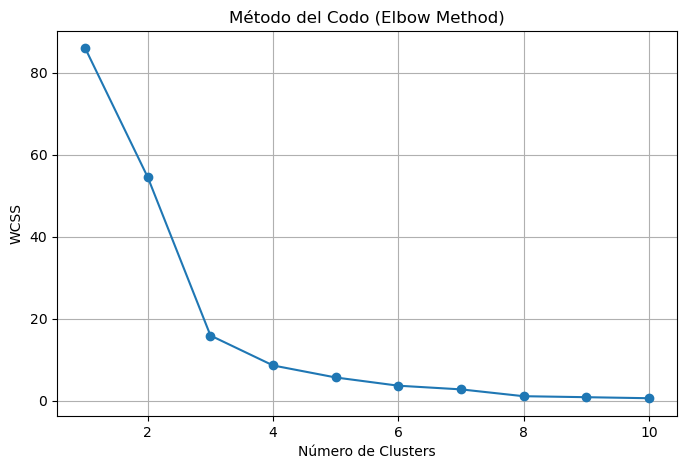

In [12]:
wcss = []  # Within-cluster sum of squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


c:\Users\denis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


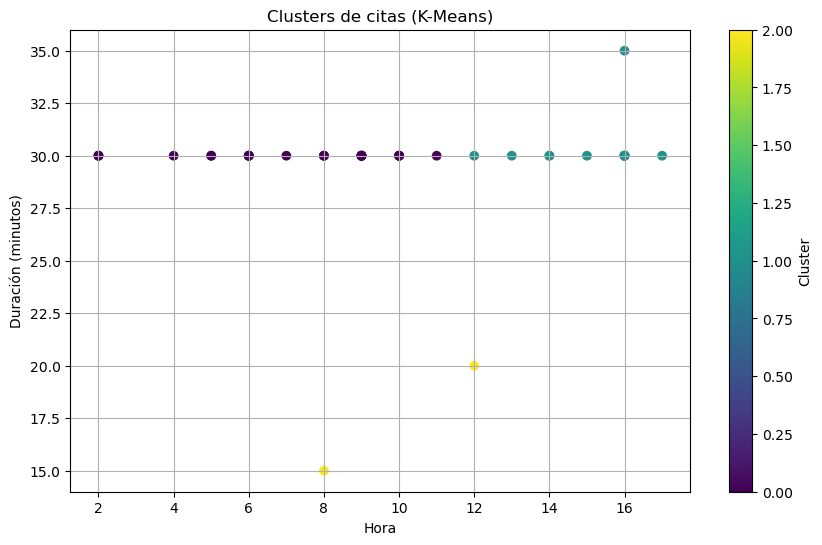

In [15]:
kmeans = KMeans(n_clusters=3, random_state=0)
df['cluster'] = kmeans.fit_predict(X_scaled)


plt.figure(figsize=(10, 6))
plt.scatter(df['hora'], df['duracion'], c=df['cluster'], cmap='viridis')
plt.xlabel('Hora')
plt.ylabel('Duración (minutos)')
plt.title('Clusters de citas (K-Means)')
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()

In [16]:
# Ver número de citas por cluster
print(df['cluster'].value_counts())

# Agrupado por cluster
print(df.groupby('cluster')[['duracion', 'hora']].mean())

cluster
0    27
1    14
2     2
Name: count, dtype: int64
          duracion       hora
cluster                      
0        30.000000   7.222222
1        30.357143  15.214286
2        17.500000  10.000000


AHORA IMPLEMENTACION NORMAL, PERO CON EL ALGORITMO HECHO EN CLASE

In [19]:
#Paso 1: Obtener e imprimir los datos inciales
df = await obtener_datos_citas()

# Ejecutar la función en un entorno Jupyter o async
import asyncio
await obtener_datos_citas()

   duracion  hora  profesor_id
0        30     7            1
1        30     9            1
2        30    10            1
3        20    12            1
4        30     2            1
   duracion  hora  profesor_id
0        30     7            1
1        30     9            1
2        30    10            1
3        20    12            1
4        30     2            1


,duracion,hora,profesor_id
0,30,7,1
1,30,9,1
2,30,10,1
3,20,12,1
4,30,2,1
5,30,5,1
6,30,5,1
7,30,6,1
8,30,8,1
9,30,8,1


In [20]:
# Paso 1: Normalizar y convertir los datos a una lista de vectores numéricos:
from sklearn.preprocessing import StandardScaler

# Selección y normalización
X_raw = df[['duracion', 'hora', 'profesor_id']]
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

headers = X_raw.columns.tolist()
datos = X.tolist()

In [24]:
# Paso 3: Algoritmo manual de K-Means
import numpy as np
import math

def imprimir_centroides(centroides):
    for i, centroide in enumerate(centroides):
        print(f"Centroide {i}: ", end="")
        for c in centroide:
            print(f"{c:.2f}\t", end="")
        print()

def calcular_nuevos_centroides(grupos):
    return [np.mean(grupo, axis=0) if grupo else [0]*len(grupos[0][0]) for grupo in grupos]

def calculo(datos, centroides):
    asignaciones = [[] for _ in range(len(centroides))]
    print("\nTabla de Comparación de Distancias")
    print("Punto - Centroide - Distancia - Pertenencia")
    print("-" * 80)
    for point in datos:
        distancias = [math.sqrt(sum((p - c) ** 2 for p, c in zip(point, centroide))) for centroide in centroides]
        index_min = np.argmin(distancias)
        for i, d in enumerate(distancias):
            print(f"{point} -> {centroides[i]} = {d:.5f}", end=" | ")
        print(f"**Cluster {index_min}**")
        asignaciones[index_min].append(point)

    print("\nPuntos agrupados por centroide:")
    for i, grupo in enumerate(asignaciones): print(f"Grupo {i} ({len(grupo)} puntos):")
    for punto in grupo:
        print(f"  {punto}")


    print("\nNuevos centroides:")
    nuevos = calcular_nuevos_centroides(asignaciones)
    imprimir_centroides(nuevos)


In [25]:
# Paso 4: Ejecutar K-Means manual con centroides iniciales

# Número de clusters
k = 3

# Usar los primeros k puntos como centroides iniciales (puedes mejorarlo con inicialización aleatoria si deseas)
centroides_iniciales = datos[:k]

print("\n--- Clustering manual con centroides iniciales ---")
calculo(datos, centroides_iniciales)



--- Clustering manual con centroides iniciales ---

Tabla de Comparación de Distancias
Punto - Centroide - Distancia - Pertenencia
--------------------------------------------------------------------------------
[0.16523847695440583, -0.6839234537054506, 0.0] -> [0.16523847695440583, -0.6839234537054506, 0.0] = 0.00000 | [0.16523847695440583, -0.6839234537054506, 0.0] -> [0.16523847695440583, -0.2207941858419171, 0.0] = 0.46313 | [0.16523847695440583, -0.6839234537054506, 0.0] -> [0.16523847695440583, 0.010770448089849635, 0.0] = 0.69469 | **Cluster 0**
[0.16523847695440583, -0.2207941858419171, 0.0] -> [0.16523847695440583, -0.6839234537054506, 0.0] = 0.46313 | [0.16523847695440583, -0.2207941858419171, 0.0] -> [0.16523847695440583, -0.2207941858419171, 0.0] = 0.00000 | [0.16523847695440583, -0.2207941858419171, 0.0] -> [0.16523847695440583, 0.010770448089849635, 0.0] = 0.23156 | **Cluster 1**
[0.16523847695440583, 0.010770448089849635, 0.0] -> [0.16523847695440583, -0.68392345370545

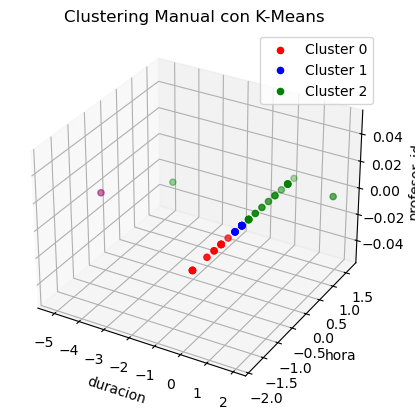

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

X_np = np.array(X)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green', 'purple', 'orange']
for i in range(k):
    puntos = np.array([p for p in datos if math.sqrt(sum((p[j] - centroides_iniciales[i][j]) ** 2 for j in range(len(p)))) == min(
        [math.sqrt(sum((p[j] - c[j]) ** 2 for j in range(len(p)))) for c in centroides_iniciales]
    )])
    ax.scatter(puntos[:, 0], puntos[:, 1], puntos[:, 2], c=colors[i], label=f'Cluster {i}')

ax.set_xlabel(headers[0])
ax.set_ylabel(headers[1])
ax.set_zlabel(headers[2])
ax.legend()
plt.title("Clustering Manual con K-Means")
plt.show()
